# All Models  R² Comparison & Best Model Analysis
**Project**: CryptoFlow Bitcoin GK Volatility Prediction  
**Purpose**: Compare Test R² across all regression models loaded from results CSV


## 1. Setup & Load Results

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, warnings
warnings.filterwarnings('ignore')

BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
RESULTS_CSV = os.path.join(BASE_DIR, 'results', 'regression_results.csv')
PLOTS_DIR   = os.path.join(BASE_DIR, 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

df = pd.read_csv(RESULTS_CSV)
print(f"Loaded {len(df)} models from {RESULTS_CSV}")
print()
print(df[['model','r2','mse','rmse','mae']].to_string(index=False))

Loaded 18 models from d:\ML\crypto project\cryptoflow\results\regression_results.csv

                         model     r2      mse     rmse      mae
          Persistence Baseline 0.1851      NaN 0.002810 0.001600
       Linear Normal (scratch) 0.3683 0.000006 0.002474 0.001615
           Linear GD (scratch) 0.3316 0.000006 0.002545 0.001754
                Linear sklearn 0.3683 0.000006 0.002474 0.001615
           MR Normal (scratch) 0.3683 0.000006 0.002474 0.001615
               MR GD (scratch) 0.3316 0.000006 0.002545 0.001754
                    MR sklearn 0.3683 0.000006 0.002474 0.001615
  Poly Normal (scratch, deg=2) 0.4011 0.000006 0.002409 0.001552
          Poly sklearn (deg=2) 0.4011 0.000006 0.002409 0.001552
      Lasso (scratch, a=5e-02) 0.3683 0.184728 0.429800 0.280544
      Lasso (sklearn, a=5e-02) 0.3657 0.185489 0.430685 0.283885
 Ridge Normal (scratch, α=0.1) 0.3683 0.184728 0.429800 0.280545
     Ridge GD (scratch, α=0.1) 0.3288 0.196275 0.443030 0.307632
    

## 2. Assign Model Families & Sort

In [8]:

def get_family(name):
    n = name.lower()
    if 'poly' in n:                          return 'Polynomial'
    if 'lasso' in n or 'ridge' in n:         return 'Regularised'
    if 'forest' in n or 'rf' in n:           return 'Ensemble'
    if 'boost' in n or 'gb' in n:            return 'Ensemble'
    if 'linear' in n or 'multiple' in n or 'mr' in n: return 'Linear'
    if 'huber' in n:                         return 'Regularised'
    return 'Other'

df['family'] = df['model'].apply(get_family)
df = df.sort_values('r2', ascending=False).reset_index(drop=True)
df['rank'] = df.index + 1

# Train R² not in CSV — we'll use r2 (test) for the main comparison
poly_baseline = df[df['family'] == 'Polynomial']['r2'].max()
best_r2       = df['r2'].max()
best_model    = df.loc[df['r2'].idxmax(), 'model']

print(f"Polynomial baseline R² : {poly_baseline:.4f}")
print(f"Best Test R²           : {best_r2:.4f}  →  {best_model}")
print()
print(f"{'Rank':<5} {'Model':<40} {'R²':>8} {'MSE':>12} {'Family'}")
print('-' * 80)
for _, r in df.iterrows():
    beat = ' ✅' if r['r2'] > poly_baseline and r['family'] != 'Polynomial' else ''
    print(f"{int(r['rank']):<5} {r['model']:<40} {r['r2']:>8.4f} {r['mse']:>12.6e} {r['family']}{beat}")

Polynomial baseline R² : 0.4011
Best Test R²           : 0.4046  →  GB Scratch (lr=0.1, trees=100)

Rank  Model                                          R²          MSE Family
--------------------------------------------------------------------------------
1     GB Scratch (lr=0.1, trees=100)             0.4046 5.770000e-06 Ensemble ✅
2     Poly Normal (scratch, deg=2)               0.4011 5.800000e-06 Polynomial
3     Poly sklearn (deg=2)                       0.4011 5.800000e-06 Polynomial
4     RF Scratch (n=20)                          0.3915 1.779399e-01 Ensemble
5     RF sklearn (n=100)                         0.3854 1.797294e-01 Ensemble
6     GB sklearn (lr=0.1, trees=100)             0.3805 6.000000e-06 Ensemble
7     Linear Normal (scratch)                    0.3683 6.120000e-06 Linear
8     Ridge sklearn (α=0.1)                      0.3683 1.847280e-01 Regularised
9     Ridge Normal (scratch, α=0.1)              0.3683 1.847280e-01 Regularised
10    Lasso (scratch, a=5e-02) 

## 3. Plot 1  R² All Models (Horizontal Bar)

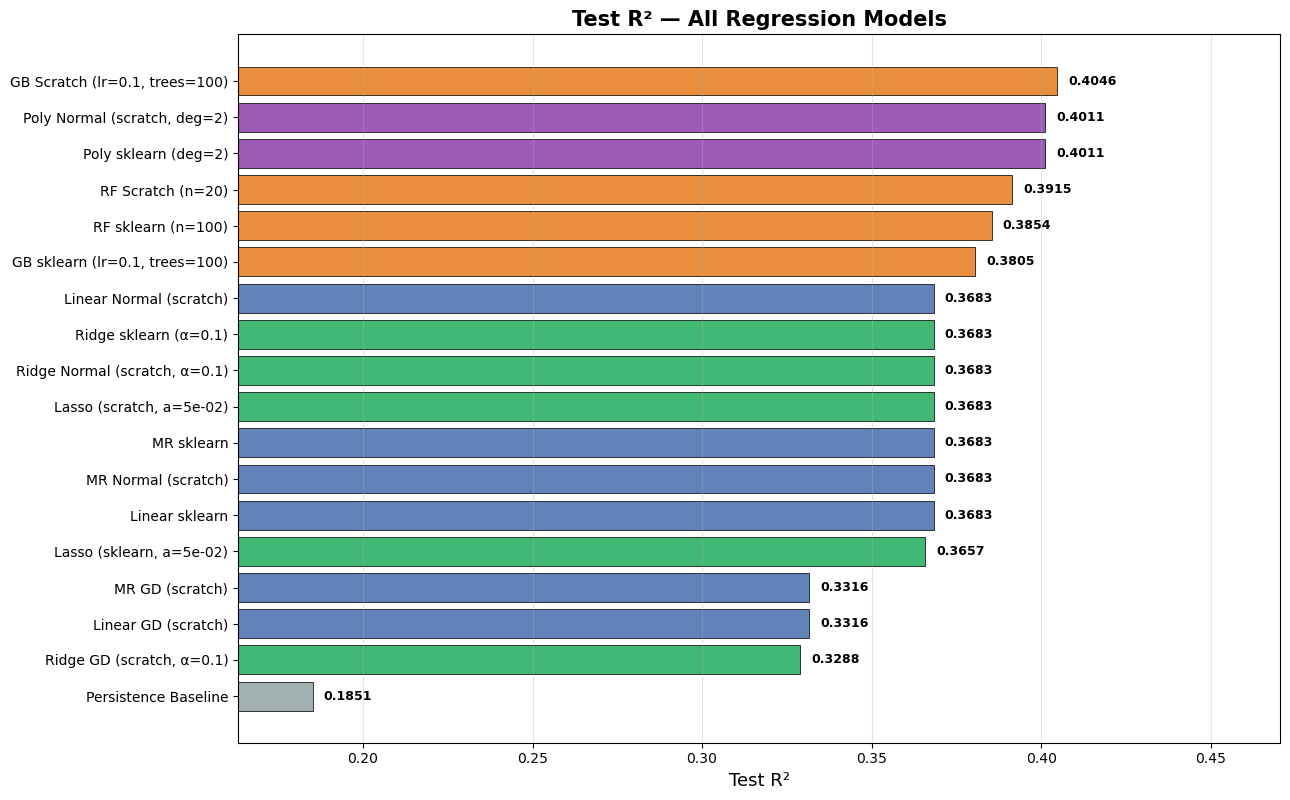

Saved: comparison_r2_all_models.png


In [9]:
type_colors = {
    'Linear':      '#4C72B0',
    'Polynomial':  '#8E44AD',
    'Regularised': '#27AE60',
    'Ensemble':    '#E67E22',
    'Other':       '#95A5A6',
}
bar_colors = [type_colors.get(f, '#95A5A6') for f in df['family']]

fig, ax = plt.subplots(figsize=(13, max(6, len(df)*0.45)))

bars = ax.barh(df['model'][::-1], df['r2'][::-1],
               color=bar_colors[::-1], edgecolor='black', linewidth=0.6, alpha=0.88)


ax.set_xlabel('Test R²', fontsize=13)
ax.set_title('Test R² — All Regression Models', fontsize=15, fontweight='bold')
ax.grid(axis='x', alpha=0.35)

margin = (df['r2'].max() - df['r2'].min()) * 0.05
ax.set_xlim(df['r2'].min() - margin*2, df['r2'].max() + margin*6)

for bar, val in zip(bars, df['r2'][::-1]):
    ax.text(val + margin*0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

patches = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items() if t in df['family'].values]


plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'comparison_r2_all_models.png'), dpi=180, bbox_inches='tight')
plt.show()
print("Saved: comparison_r2_all_models.png")

## 4. Plot 2  Best Model per Family

=== Best Model per Family ===
  Ensemble        GB Scratch (lr=0.1, trees=100)            R²=0.4046
  Polynomial      Poly Normal (scratch, deg=2)              R²=0.4011
  Linear          Linear Normal (scratch)                   R²=0.3683
  Regularised     Ridge sklearn (α=0.1)                     R²=0.3683
  Other           Persistence Baseline                      R²=0.1851


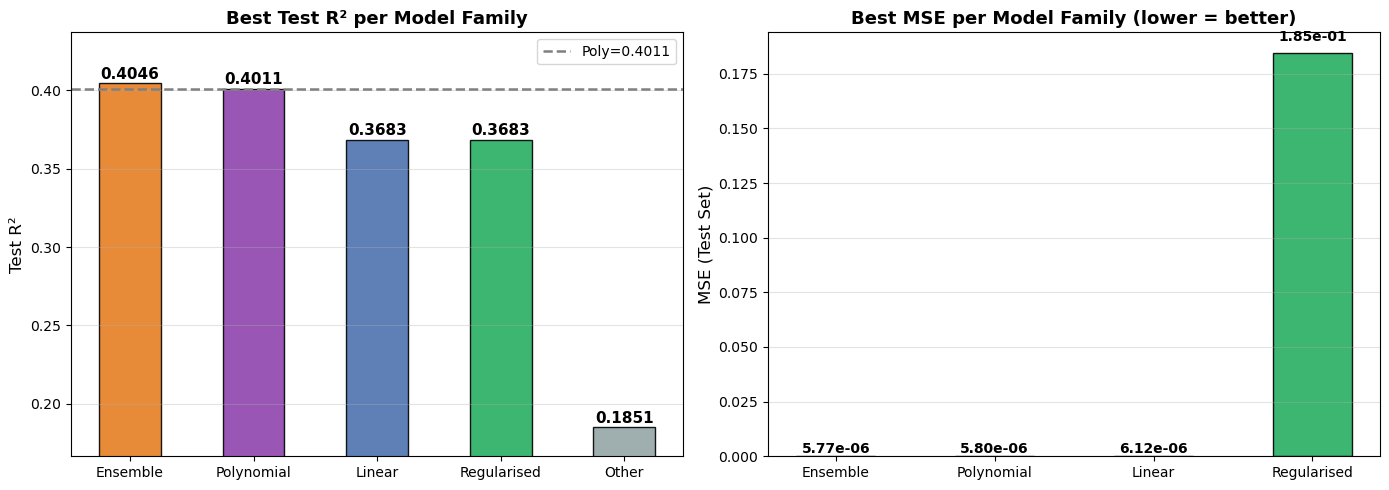

Saved: comparison_best_per_family.png


In [10]:
best_per_family = (df.groupby('family')
                     .apply(lambda x: x.loc[x['r2'].idxmax()])
                     .reset_index(drop=True)
                     .sort_values('r2', ascending=False))

print("=== Best Model per Family ===")
for _, r in best_per_family.iterrows():
    print(f"  {r['family']:<14}  {r['model']:<40}  R²={r['r2']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² per family
colors_fam = [type_colors.get(f,'#95A5A6') for f in best_per_family['family']]
bars = axes[0].bar(best_per_family['family'], best_per_family['r2'],
                    color=colors_fam, edgecolor='black', width=0.5, alpha=0.9)
axes[0].axhline(poly_baseline, color='grey', ls='--', lw=1.8, label=f'Poly={poly_baseline:.4f}')
axes[0].set_ylabel('Test R²', fontsize=12)
axes[0].set_title('Best Test R² per Model Family', fontsize=13, fontweight='bold')
axes[0].set_ylim(df['r2'].min()*0.9, df['r2'].max()*1.08)
axes[0].grid(axis='y', alpha=0.35)
axes[0].legend()
for bar, (_, r) in zip(bars, best_per_family.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{r["r2"]:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# MSE per family (lower = better)
bars2 = axes[1].bar(best_per_family['family'], best_per_family['mse'],
                     color=colors_fam, edgecolor='black', width=0.5, alpha=0.9)
axes[1].set_ylabel('MSE (Test Set)', fontsize=12)
axes[1].set_title('Best MSE per Model Family (lower = better)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.35)
for bar, (_, r) in zip(bars2, best_per_family.iterrows()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                 f'{r["mse"]:.2e}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'comparison_best_per_family.png'), dpi=180, bbox_inches='tight')
plt.show()
print("Saved: comparison_best_per_family.png")

## 5. Plot 3  Scratch vs sklearn Head-to-Head

Scratch models : 10
sklearn models : 8


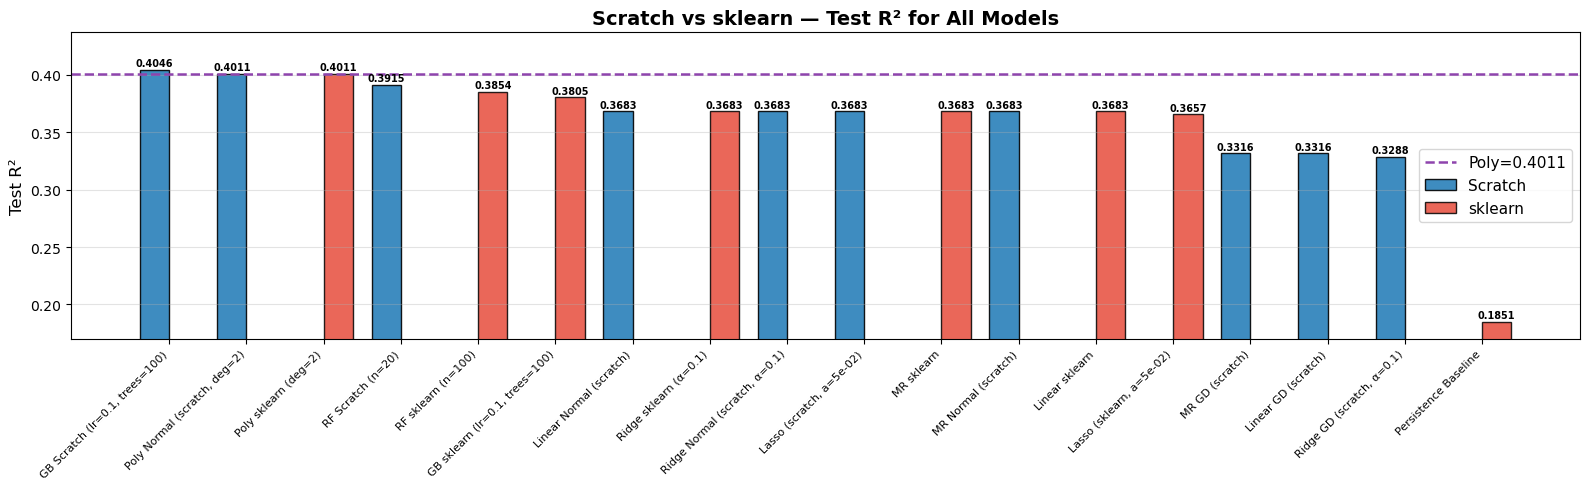

Saved: comparison_scratch_vs_sklearn.png


In [11]:
# Pair up scratch vs sklearn automatically by detecting keywords
scratch = df[df['model'].str.lower().str.contains('scratch|normal|gd')].copy()
sklearn = df[~df['model'].str.lower().str.contains('scratch|normal|gd')].copy()

print(f"Scratch models : {len(scratch)}")
print(f"sklearn models : {len(sklearn)}")

x  = np.arange(len(df))
w  = 0.38

fig, ax = plt.subplots(figsize=(16, 5))
s_mask = df['model'].str.lower().str.contains('scratch|normal eq|gd')
b1 = ax.bar(x[s_mask]  - w/2, df.loc[s_mask,  'r2'], w,
            label='Scratch', color='#2980B9', edgecolor='black', alpha=0.9)
b2 = ax.bar(x[~s_mask] + w/2, df.loc[~s_mask, 'r2'], w,
            label='sklearn', color='#E74C3C', edgecolor='black', alpha=0.85)

ax.axhline(poly_baseline, color='#8E44AD', ls='--', lw=1.8, label=f'Poly={poly_baseline:.4f}')
ax.set_xticks(x)
ax.set_xticklabels(df['model'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Test R²', fontsize=12)
ax.set_title('Scratch vs sklearn — Test R² for All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.35)
ax.set_ylim(df['r2'].min()*0.92, df['r2'].max()*1.08)

for i, (_, r) in enumerate(df.iterrows()):
    is_scratch = s_mask.iloc[i]
    xpos = i - w/2 if is_scratch else i + w/2
    ax.text(xpos, r['r2'] + 0.001, f'{r["r2"]:.4f}',
            ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'comparison_scratch_vs_sklearn.png'), dpi=180, bbox_inches='tight')
plt.show()
print("Saved: comparison_scratch_vs_sklearn.png")

## 6. Final Summary

In [ ]:
print("=" * 70)
print("  ALL MODELS — FINAL R² COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Rank':<5} {'Model':<40} {'R²':>8} {'MSE':>12}")
print("-" * 70)
for _, r in df.iterrows():
    star = "  ← BEST" if r['rank'] == 1 else ""
    beat = "  ✅ beats Poly" if r['r2'] > poly_baseline else ""
    print(f"{int(r['rank']):<5} {r['model']:<40} {r['r2']:>8.4f} {r['mse']:>12.6e}{star}{beat}")
print("-" * 70)
print(f"\nPolynomial baseline R² = {poly_baseline:.4f}")
models_beating = df[df['r2'] > poly_baseline]
print(f"Models beating Poly    : {len(models_beating)}")
for _, r in models_beating.iterrows():
    print(f"  ✅ {r['model']:<40} R²={r['r2']:.4f} ")
print("=" * 70)

  ALL MODELS — FINAL R² COMPARISON SUMMARY
Rank  Model                                          R²          MSE
----------------------------------------------------------------------
1     GB Scratch (lr=0.1, trees=100)             0.4046 5.770000e-06  ← BEST  ✅ beats Poly
2     Poly Normal (scratch, deg=2)               0.4011 5.800000e-06
3     Poly sklearn (deg=2)                       0.4011 5.800000e-06
4     RF Scratch (n=20)                          0.3915 1.779399e-01
5     RF sklearn (n=100)                         0.3854 1.797294e-01
6     GB sklearn (lr=0.1, trees=100)             0.3805 6.000000e-06
7     Linear Normal (scratch)                    0.3683 6.120000e-06
8     Ridge sklearn (α=0.1)                      0.3683 1.847280e-01
9     Ridge Normal (scratch, α=0.1)              0.3683 1.847280e-01
10    Lasso (scratch, a=5e-02)                   0.3683 1.847277e-01
11    MR sklearn                                 0.3683 6.120000e-06
12    MR Normal (scratch)           